In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
df = pd.read_csv('/content/netflix_titles (1).csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [17]:
print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description     

In [20]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['date_added'] = df['date_added'].fillna('Unknown')
df['duration'] = df['duration'].fillna('0 min')


In [21]:
print(df.isnull().sum())


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [22]:
type_counts = df['type'].value_counts()

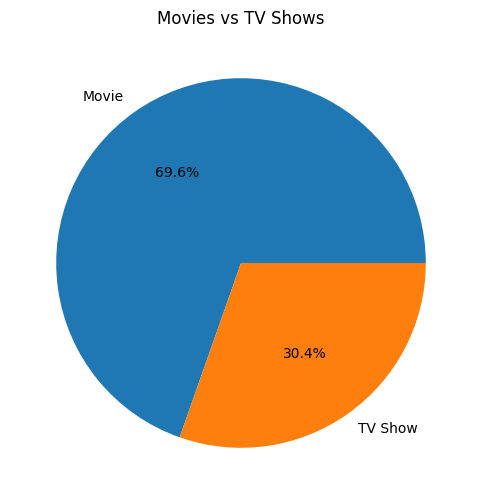

In [23]:
plt.figure(figsize=(6,6))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%'
)
plt.title("Movies vs TV Shows")
plt.show()


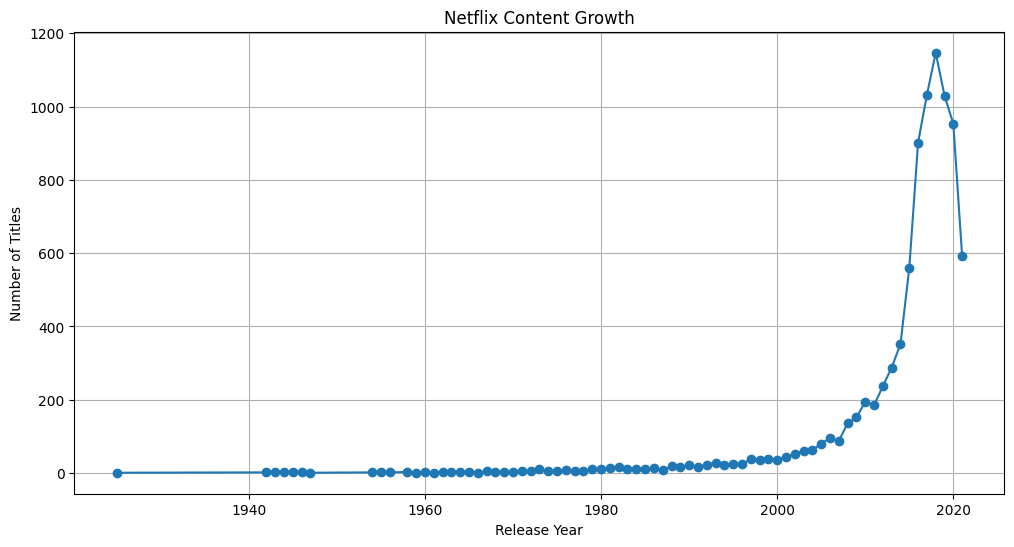

In [24]:

year_counts = df['release_year'].value_counts().sort_index()


plt.figure(figsize=(12,6))
plt.plot(
    year_counts.index,
    year_counts.values,
    marker='o'
)

plt.title("Netflix Content Growth")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()


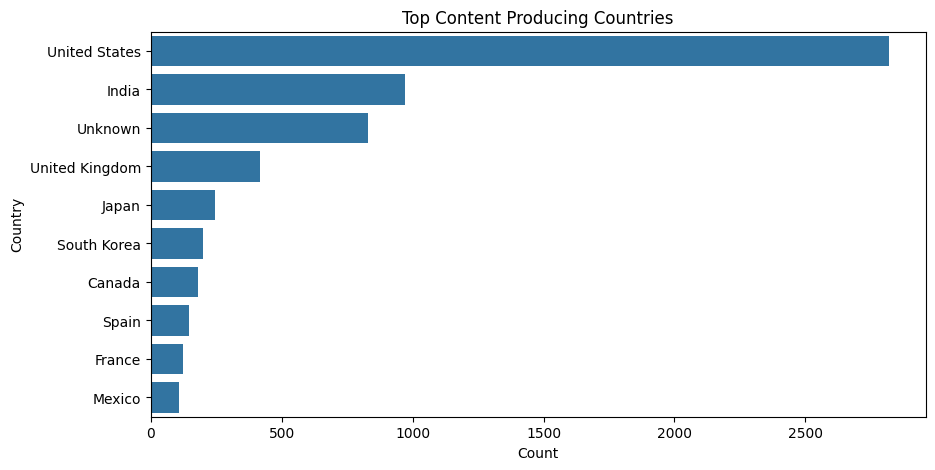

In [25]:

country_count = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=country_count.values,
    y=country_count.index
)

plt.title("Top Content Producing Countries")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

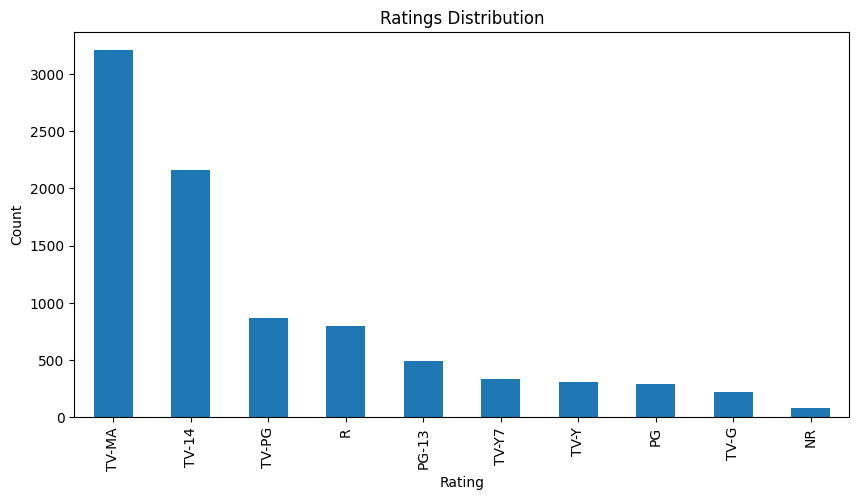

In [26]:
plt.figure(figsize=(10,5))

df['rating'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

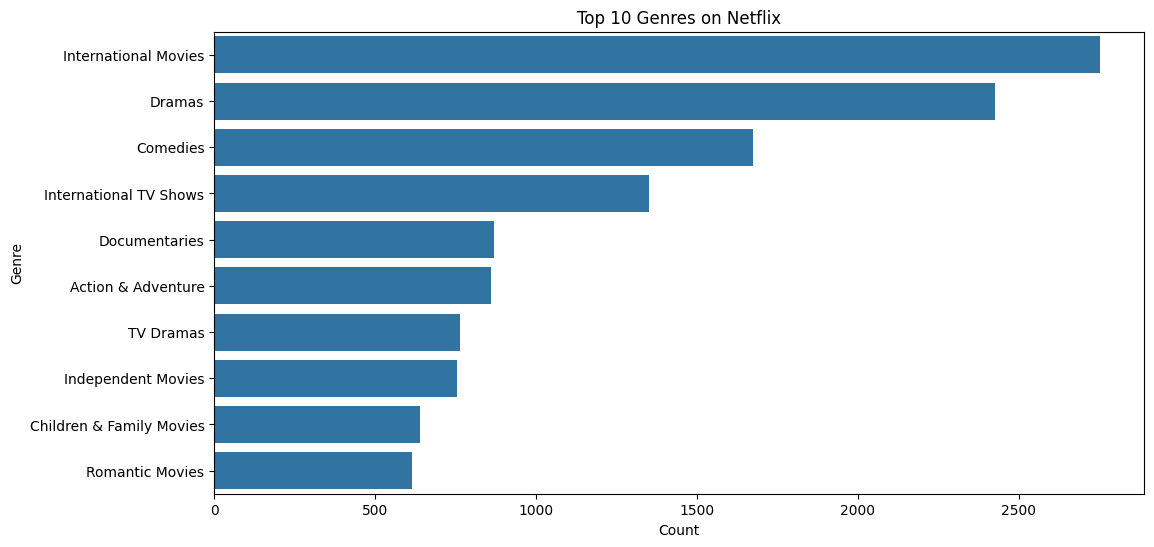

In [27]:
genres = df['listed_in'].str.split(', ').explode()

genre_count = genres.value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=genre_count.values,
    y=genre_count.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()


In [28]:

fig = px.histogram(
    df,
    x="release_year",
    color="type",
    title="Content by Year & Type",
    barmode="overlay"
)

fig.show()

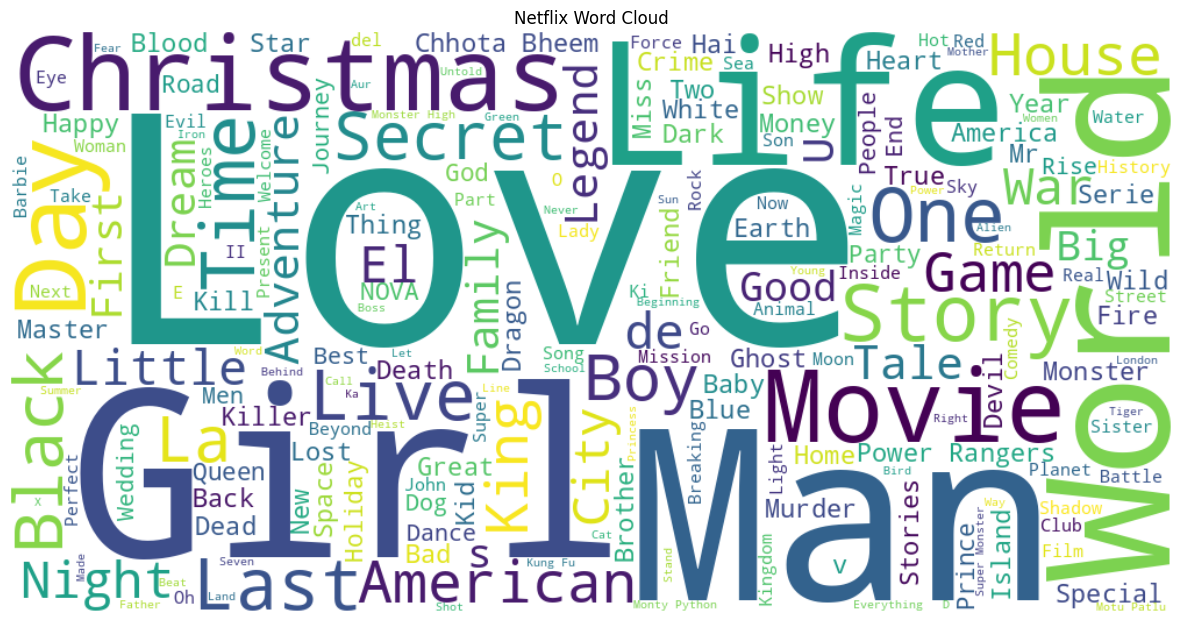

In [29]:
text = " ".join(df['title'].dropna())

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Netflix Word Cloud")
plt.show()

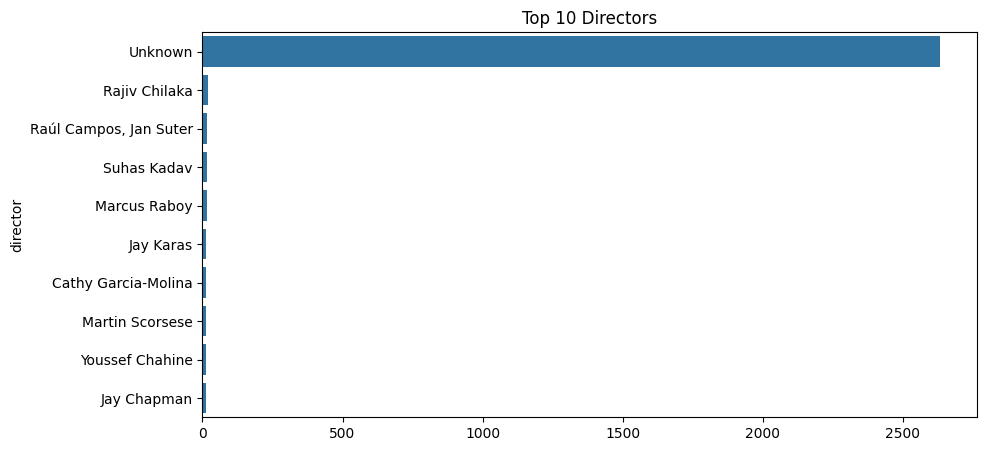

In [32]:
top_directors = df['director'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top 10 Directors")

plt.show()

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df['description'] = df['description'].fillna('')

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['description'])

cosine_sim = cosine_similarity(tfidf_matrix)

In [34]:
def recommend(title):

    idx = df[df['title'] == title].index[0]

    scores = list(enumerate(cosine_sim[idx]))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    scores = scores[1:6]

    movie_indices = [i[0] for i in scores]

    return df['title'].iloc[movie_indices]

recommend("Narcos")

,title
7463,Miss Dynamite
6673,El Cartel 2
2921,Narcos: Mexico
4750,El Chapo
310,Cocaine Cowboys: The Kings of Miami


In [35]:
print("Volume  : Thousands of Netflix records")
print("Variety : Movies, TV Shows, Genres, Ratings")
print("Velocity: Content added every year")
print("Veracity: Missing values cleaned")
print("Value   : Business insights generated")

Volume  : Thousands of Netflix records
Variety : Movies, TV Shows, Genres, Ratings
Velocity: Content added every year
Veracity: Missing values cleaned
Value   : Business insights generated
